In [1]:
import pandas as pd
from sklearn.preprocessing import RobustScaler
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("D:\\Users\\PC\\Escritorio\\Portafolio\\customer-segmentation-financial\\data\\CC GENERAL.csv")

#Primeramente cargamos el dataset, y obsevamos las 10 primeras filas para poder ver que tipos de datos podemos llegar a ver en el dataset

df.head(10)

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.00,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12
5,C10006,1809.828751,1.000000,1333.28,0.00,1333.28,0.000000,0.666667,0.000000,0.583333,0.000000,0,8,1800.0,1400.057770,2407.246035,0.000000,12
6,C10007,627.260806,1.000000,7091.01,6402.63,688.38,0.000000,1.000000,1.000000,1.000000,0.000000,0,64,13500.0,6354.314328,198.065894,1.000000,12
7,C10008,1823.652743,1.000000,436.20,0.00,436.20,0.000000,1.000000,0.000000,1.000000,0.000000,0,12,2300.0,679.065082,532.033990,0.000000,12
8,C10009,1014.926473,1.000000,861.49,661.49,200.00,0.000000,0.333333,0.083333,0.250000,0.000000,0,5,7000.0,688.278568,311.963409,0.000000,12
9,C10010,152.225975,0.545455,1281.60,1281.60,0.00,0.000000,0.166667,0.166667,0.000000,0.000000,0,3,11000.0,1164.770591,100.302262,0.000000,12


In [2]:
df.shape
#shape -> Mirar las dimensiones del dataset, contamos con 18 columnas y 8950 filas

(8950, 18)

In [3]:
df.info()
#info -> Con info() podemos observar de manera rápida que tipo de datos hay en cada columna, ya sean int, float, object entre otros.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [4]:
df= df.drop("CUST_ID", axis=1)

#Se quita la columna que no posee datos númericos y que no es relevante para el análisis.

In [5]:
df.isnull().sum()
#isnull() ->verifica que datos sean "nulos" o "faltantes" y con el .sum() los sumamos para saber el total de los datos faltantes.

BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64

In [6]:
df[df['CREDIT_LIMIT'].isnull()]

#Observamos al cliente que no tiene limite en crédito.

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
5203,18.400472,0.166667,0.0,0.0,0.0,186.853063,0.0,0.0,0.0,0.166667,1,0,NaN,9.040017,14.418723,0.0,6


In [7]:
df[df['MINIMUM_PAYMENTS'].isnull()]
#Miramos a los usuarios que no tienen un pago minimo generado.

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.0,12
45,2242.311686,1.000000,437.00,97.00,340.0,184.648692,0.333333,0.083333,0.333333,0.166667,2,5,2400.0,0.000000,NaN,0.0,12
47,3910.111237,1.000000,0.00,0.00,0.0,1980.873201,0.000000,0.000000,0.000000,0.500000,7,0,4200.0,0.000000,NaN,0.0,12
54,6.660517,0.636364,310.00,0.00,310.0,0.000000,0.666667,0.000000,0.666667,0.000000,0,8,1000.0,417.016763,NaN,0.0,12
55,1311.995984,1.000000,1283.90,1283.90,0.0,0.000000,0.250000,0.250000,0.000000,0.000000,0,6,6000.0,0.000000,NaN,0.0,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8919,14.524779,0.333333,152.00,152.00,0.0,0.000000,0.333333,0.333333,0.000000,0.000000,0,2,1500.0,0.000000,NaN,0.0,6
8929,371.527312,0.333333,0.00,0.00,0.0,1465.407927,0.000000,0.000000,0.000000,0.166667,5,0,1500.0,0.000000,NaN,0.0,6
8935,183.817004,1.000000,465.90,0.00,465.9,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1500.0,0.000000,NaN,0.0,6
8944,193.571722,0.833333,1012.73,1012.73,0.0,0.000000,0.333333,0.333333,0.000000,0.000000,0,2,4000.0,0.000000,NaN,0.0,6


In [8]:
df.describe()
#describe -> Con df describe podemos ver los promedios, los cuantiles, desviaciones, los valores minimos y maximos

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


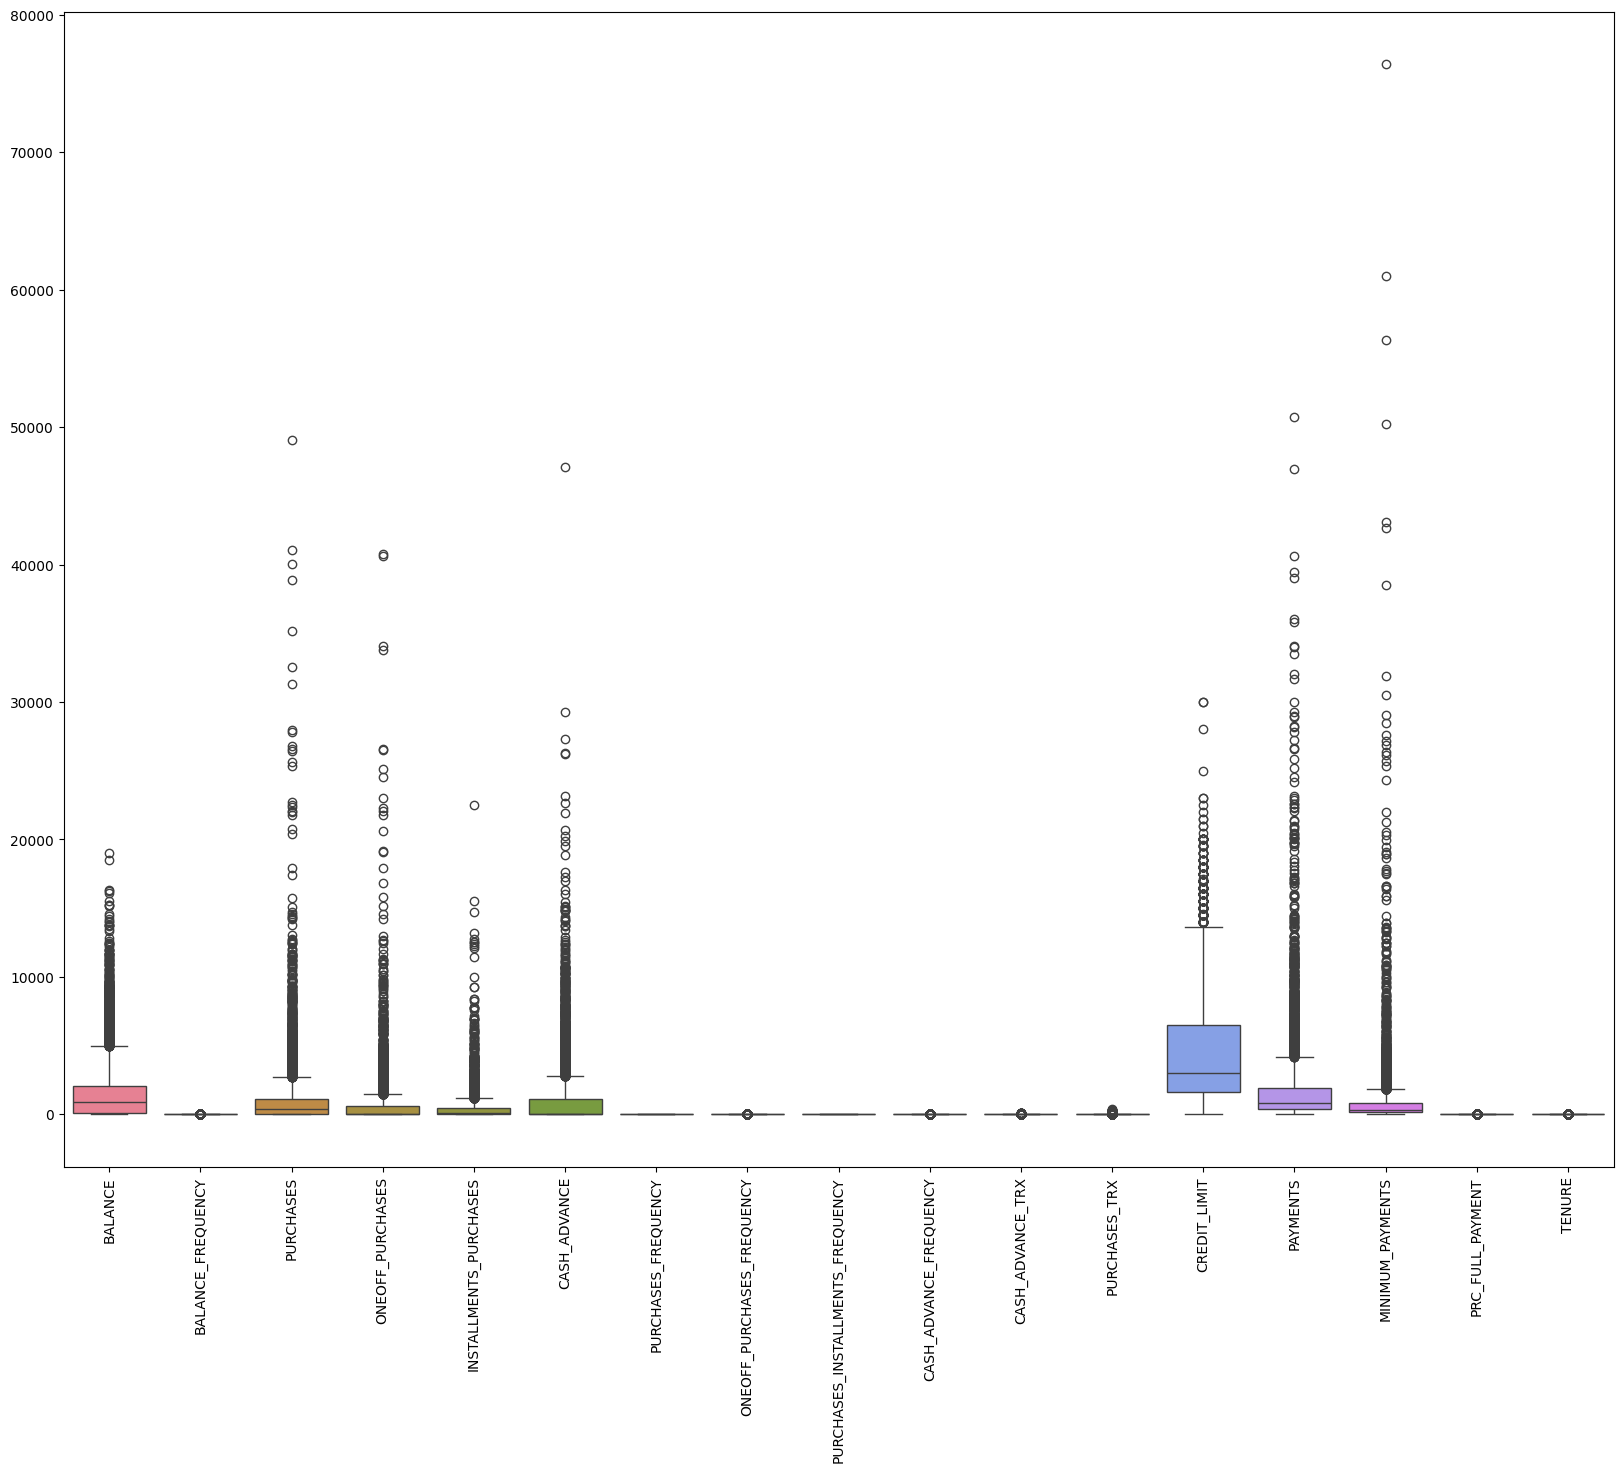

In [9]:
plt.figure(figsize=(20,15))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

#Hacemos un diagrama de cajas y bigotes (boxplot), donde podemos ver la gran cantidad de outliers
# y el porque usamos la mediana en ves de la media

In [10]:
df.fillna(df.median(), inplace=True)

#Rellenamos los datos con la mediana, ya que si miramos el paso anterior en el decribe
#el promedio está muy por encima de la mediana, eso ocurre por que hay demasiados outliers y afectan la medida de la media

In [11]:
df.isnull().sum()
#Se verifican que ya no hayan datos faltantes

BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        0
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
dtype: int64

In [ ]:
from sklearn.preprocessing import StandardScaler
import numpy as np
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

#Escalamos el modelo, para que todo quede dentro de una misma escala,
#ya que como se vió anteriormente hay datos entre 0 a 9000 en diferentes columnas
#Con esto logramos dejar todo en una escala "parecida"

In [ ]:
np.mean(X_scaled,axis=0)

#Podemos ver que la media de todas las columnas es practicamente 0

array([-2.54048799e-17,  1.58780500e-16,  3.17560999e-18, -6.03365899e-17,
        3.17560999e-17, -6.35121998e-18,  9.32835435e-17,  1.90536600e-17,
        5.71609799e-17, -1.59574402e-16, -1.74658550e-17, -1.90536600e-17,
        1.01619520e-16, -2.54048799e-17,  1.27024400e-17, -9.52682998e-18,
        2.92156119e-16])

In [ ]:
np.std(X_scaled,axis=0)

#Y la desviación es 1

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

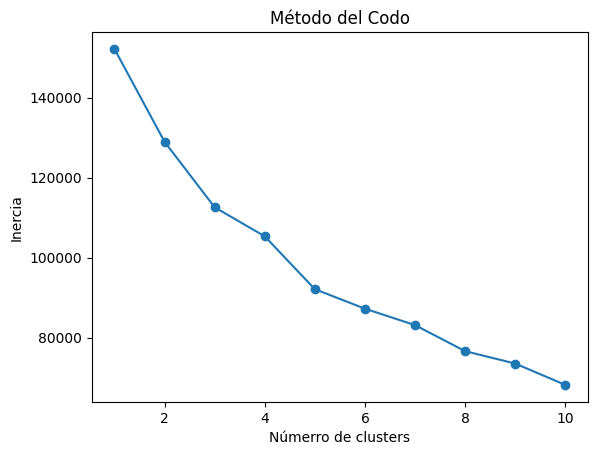

In [ ]:
from sklearn.cluster import KMeans

inertia = []

for k in range(1,11):
    kmeans = KMeans(n_clusters=k,random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1,11), inertia , marker= 'o')
plt.xlabel("Númerro de clusters")
plt.ylabel("Inercia")
plt.title("Método del Codo")
plt.show()

#Utilizamos un modelo llamado "Elbow Method", donde usamos la inertia, donde la damos un número 
#determinado de clusters y donde veamos el "codo" ese sería el número aconsejable de clusters que vamos a utilizar,
#ya que a mayor cantidad de clusters se supone que es mejor, pero no es recomendable, ya que el número de los clusters es muy bajo
#en está gráfica sería recomendable usar el 4 o el 5 ya que se evidencia una especie de "codo"

In [ ]:
from sklearn.metrics import silhouette_score

kmeans_4 = KMeans(n_clusters = 4, random_state=42)
labels_4 = kmeans_4.fit_predict(X_scaled)
sil_4 = silhouette_score(X_scaled,labels_4)

kmeans_5 = KMeans(n_clusters = 5, random_state=42)
labels_5 = kmeans_5.fit_predict(X_scaled)
sil_5 = silhouette_score(X_scaled,labels_5)

sil_4,sil_5

#Según la gráfica lo recomendable sería usar entre 4 o 5 clusters,
#entonces lo que hay que hacer es comparar con Silhouette Score cada uno de los clusters
# Si el score es más alto, nos esta indicando que es mejor por su separación
#ya que evalua que tan lejos está de otros cluster y que tan cerca está de su propio cluster

(0.1664601900140412, 0.19256596919095406)

In [ ]:
kmeansd = KMeans(n_clusters=5,random_state=42)
df['Cluster'] = kmeansd.fit_predict(X_scaled)

#Por lo que seleccionamos al final 5 clusters y agregamos esa columan a nuestro dataFrame

In [ ]:
df['Cluster'].value_counts()

#Revisamos la cantidad de clientes que quedaron por cluster

Cluster
2    3164
3    3047
4    1357
0     987
1     395
Name: count, dtype: int64

In [ ]:
cluster_profile = df.groupby('Cluster').mean()
cluster_profile

#Miramos cada una de las caracteristicas que se generaron por clusters

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
Cluster,,,,,,,,,,,,,,,,,
0,4903.428600,0.967095,553.101884,348.463283,204.741611,4983.093638,0.313999,0.153460,0.204131,0.507563,15.499493,8.604863,8062.618587,3858.809663,2071.363910,0.038158,11.413374
1,3588.990384,0.986874,7815.732886,5203.519089,2613.732785,661.788641,0.944730,0.740963,0.785823,0.071074,2.106329,90.351899,9769.620253,7409.095001,1987.582011,0.291103,11.949367
2,930.357741,0.962886,1299.705338,633.167216,666.735496,226.754889,0.897121,0.313579,0.719275,0.044345,0.828382,23.034766,4272.477078,1388.751132,645.167360,0.264987,11.610303
3,1526.118239,0.965743,255.461815,206.435714,49.375189,794.776687,0.159002,0.090819,0.067276,0.160534,3.037742,2.882179,3244.229297,958.642822,804.541051,0.022057,11.508369
4,111.260364,0.381755,335.222822,199.440295,136.001245,325.747598,0.281932,0.072926,0.198278,0.037617,0.788504,4.279293,3687.354049,1076.939244,176.594237,0.233951,11.270450


In [ ]:
columnas_interes = ['BALANCE', 'PURCHASES', 'CREDIT_LIMIT', 'PAYMENTS']
cluster_profile[columnas_interes]

#Miramos las columnas que realmente nos indican que tipo de clientes hay en cada cluster

,BALANCE,PURCHASES,CREDIT_LIMIT,PAYMENTS
Cluster,,,,
0,4903.428600,553.101884,8062.618587,3858.809663
1,3588.990384,7815.732886,9769.620253,7409.095001
2,930.357741,1299.705338,4272.477078,1388.751132
3,1526.118239,255.461815,3244.229297,958.642822
4,111.260364,335.222822,3687.354049,1076.939244


In [21]:
columnas = ["BALANCE","PAYMENTS","MINIMUM_PAYMENTS","PURCHASES"]

for cluster_id, fila in cluster_profile[columnas].iterrows():
    print(f"\n=== Resumen del Cluster {cluster_id} ===")
    print(fila)



=== Resumen del Cluster 0 ===
BALANCE             4903.428600
PAYMENTS            3858.809663
MINIMUM_PAYMENTS    2071.363910
PURCHASES            553.101884
Name: 0, dtype: float64

=== Resumen del Cluster 1 ===
BALANCE             3588.990384
PAYMENTS            7409.095001
MINIMUM_PAYMENTS    1987.582011
PURCHASES           7815.732886
Name: 1, dtype: float64

=== Resumen del Cluster 2 ===
BALANCE              930.357741
PAYMENTS            1388.751132
MINIMUM_PAYMENTS     645.167360
PURCHASES           1299.705338
Name: 2, dtype: float64

=== Resumen del Cluster 3 ===
BALANCE             1526.118239
PAYMENTS             958.642822
MINIMUM_PAYMENTS     804.541051
PURCHASES            255.461815
Name: 3, dtype: float64

=== Resumen del Cluster 4 ===
BALANCE              111.260364
PAYMENTS            1076.939244
MINIMUM_PAYMENTS     176.594237
PURCHASES            335.222822
Name: 4, dtype: float64


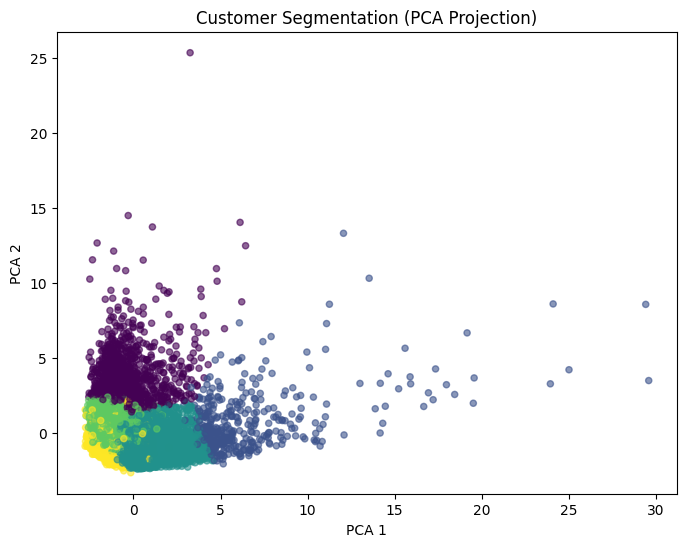

In [ ]:
from sklearn.decomposition import PCA   

pca = PCA(n_components=2)
components = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

plt.scatter(
    components[:,0],
    components[:,1],
    c=df['Cluster'],
    s=20,
    alpha=0.6
)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Customer Segmentation (PCA Projection)")

plt.show()

#Aquí usamos la bliblioteca PCA (Principal Component Analysis)
# En pocas palabras nos muestra la distribución de los clientes
#Pero lo hace en un plano de 2 dimensiones, ya que nuestro DataFrame originalmente tiene 17

In [ ]:
pca.explained_variance_ratio_

#Con este metodo de PCA podemos ver la cantidad evaluada,
# PCA1 -> explica el 27% de la info
# PCA2 -> Explica el 20% de la info

array([0.27297671, 0.2031378 ])

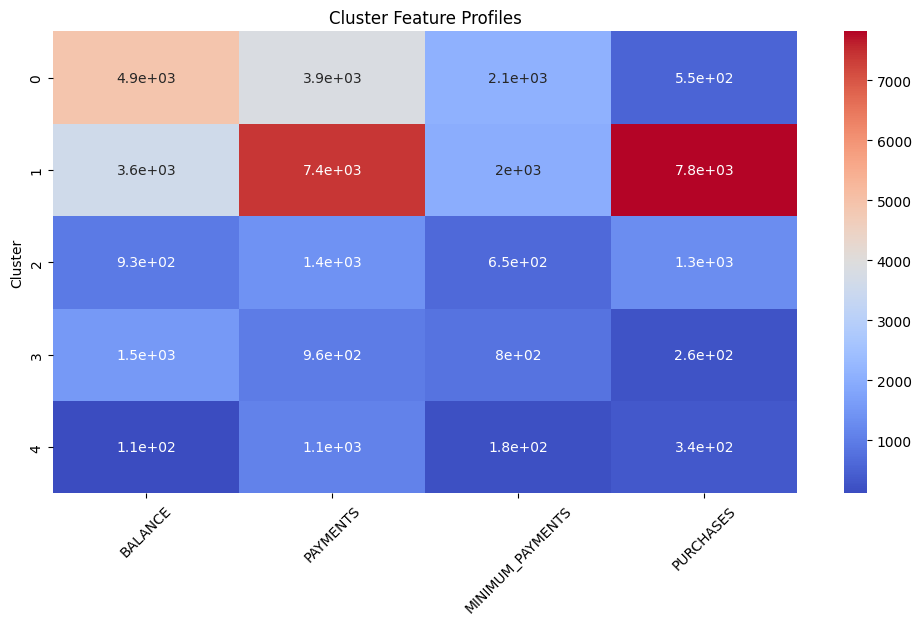

In [ ]:
plt.figure(figsize=(12,6))
sns.heatmap(cluster_profile[columnas],cmap="coolwarm",annot=True)

plt.title("Cluster Feature Profiles")
plt.xticks(rotation=45)
plt.show()

#Por ultimo creamos un mapa de calor, para ver las correlaciones de las variables con sus respectivos clusters
#Podemos evidenciar diferentes patrones de cada uno de los clientes
#Desde clientes que gastan mucho, tienen bastante creditos (VIP)
#Hasta clientes que no son de un uso frecuente